<a href="https://colab.research.google.com/github/HerreroCar/7-13-phi-framework/blob/main/TdP_Final_Core.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

# Red Π (TdP) Framework: The City of Crystal

### *Topological Predictions in -Holonomy Compactifications*

This Notebook implements the calculation engine and experimental validation for the **TdP (Pinch Theory)** framework. We present a unified perspective where both visible CP violation and Dark Matter mass scales emerge from a single topological object: the Nikulin lattice of K3 fibers.

---

### 📄 Official Documentation

#### **1. Line A - Part I: The Visible Sector (CP Violation)**

> **[TdP_Topological_Anomaly.pdf](https://github.com/HerreroCar/7-13-phi-framework/blob/main/TdP_Topological_Anomaly.pdf)** > **Focus:** Parameter-free numerical correspondence for .
> **Core:** Reports the observation that  emerges from the Betti numbers () of a Nikulin-invariant  manifold.

#### **2. Line A - Part II: The Theory (Dynamical Motivation)**

> **[TdP_Topological_Anomaly_v2.2.pdf](https://github.com/HerreroCar/7-13-phi-framework/blob/main/TdP_Topological_Anomaly_v2.2.pdf)**
> **Focus:** Physical mechanism and M2-instanton scaling.

#### **3. Line B: The Shadow Sector (Dark Matter)**

> **[Red_Π_-_City_of_Crystal.pdf](https://github.com/HerreroCar/7-13-phi-framework/blob/main/Red%20%CE%A0%20-%20City%20of%20Crystal.pdf)**
> **Focus:** Geometric Scaling for Fermionic Dark Matter.
> **Core:** Introduces the **Geometric Normalization Conjecture (GNC)**. It derives a darkino mass  keV from the anti-invariant lattice (), matching the **RAR model** for Sgr A* with a 1.4% error. **Falsifiable by S2 star precession (2026-2028).**


#### **4. Repository**

> **Main Hub:** [github.com/HerreroCar/7-13-phi-framework](https://github.com/HerreroCar/7-13-phi-framework/)

---

### 🛠️ Framework Structure

1. **Topological Core (Line A):** Strict implementation of the CP ansatz:

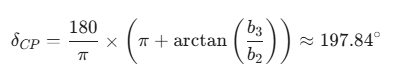

2. **Shadow Core (Line B):** Implementation of the GNC mass scaling:

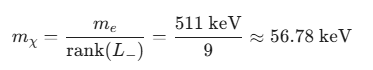

3. **Experimental Validation:** Statistical comparison with **NuFit 6.0**, **DUNE (2030)**, and **GRAVITY+/EHT** astrometry for Sgr A*.

---

> *"Life and physics are optimized geometry."*

---



## LINE A - PART I: The Falsification Engine (Core Line A)
### *Topological Anomaly & Experimental Benchmarking*

This section implements the **v1.0** core logic (as described in `TdP_Topological_Anomaly.pdf`). It focuses strictly on the numerical correspondence and its distance from current experimental data.

**Key Objective:** Provide a clear, parameter-free prediction to be tested by DUNE.

* **Inputs:** Betti numbers $(b_2=13, b_3=7)$ from Nikulin Lattice.
* **Target:** $\delta_{CP} \approx 197.8^\circ$
* **Status:** Comparison against **NuFit 5.3** (Global Fit).

In [4]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
TdP_Final_Core.py
=================

Topological Prediction Framework for the Leptonic CP Phase
Based on G₂ Compactification with Nikulin Involution

This module implements the parameter-free calculation of δ_CP from
the Betti numbers of a G₂-holonomy manifold constructed via Twisted
Connected Sums with Nikulin involution.

Structure:
    - TopologicalCore: The falsifiable prediction (δ_CP only)
    - GeometricScalingHypotheses: Speculative mass relations (clearly separated)
    - ExperimentalValidation: Comparison with data and falsification criteria

Author: Red Π Collaboration
Version: 3.0 (Line A - Keplerian Austerity)
License: Academic use
"""

from dataclasses import dataclass
from typing import Tuple, Dict
import math

# ==============================================================================
# CONSTANTS
# ==============================================================================

PI = math.pi
PHI = (1 + math.sqrt(5)) / 2  # Golden ratio (used only in speculative section)


# ==============================================================================
# PART I: TOPOLOGICAL CORE (FALSIFIABLE)
# ==============================================================================

@dataclass(frozen=True)
class NikulinLattice:
    """
    The Nikulin involution lattice L₊ ≅ E₈(-1) ⊕ U ⊕ U ⊕ ⟨-2⟩.

    This is the mathematical foundation of the entire framework.
    The lattice structure is FIXED by the classification of Nikulin
    involutions on K3 surfaces (Nikulin, 1979).

    Properties:
        rank_E8: Rank of E₈(-1) component = 8
        rank_U1: Rank of first hyperbolic plane U = 2
        rank_U2: Rank of second hyperbolic plane U = 2
        rank_minus2: Rank of ⟨-2⟩ component = 1
    """
    rank_E8: int = 8
    rank_U1: int = 2
    rank_U2: int = 2
    rank_minus2: int = 1

    @property
    def rank_L_plus(self) -> int:
        """Rank of invariant lattice L₊."""
        return self.rank_E8 + self.rank_U1 + self.rank_U2 + self.rank_minus2

    @property
    def rank_L_minus(self) -> int:
        """Rank of anti-invariant lattice L₋ = 22 - rank(L₊)."""
        return 22 - self.rank_L_plus  # 22 = rank(H²(K3))

    def __str__(self) -> str:
        return f"E₈(-1) ⊕ U ⊕ U ⊕ ⟨-2⟩, rank = {self.rank_L_plus}"


@dataclass(frozen=True)
class G2Manifold:
    """
    A G₂-holonomy manifold X₇ constructed via Twisted Connected Sum
    with Nikulin involution.

    The Betti numbers are DETERMINED by the Nikulin lattice, not chosen.

    Reference: Corti-Haskins-Nordström-Pacini, Duke Math. J. 164 (2015)
    """
    lattice: NikulinLattice

    @property
    def b2(self) -> int:
        """Second Betti number b₂(X₇) = rank(L₊)."""
        return self.lattice.rank_L_plus

    @property
    def b3(self) -> int:
        """Third Betti number b₃(X₇) = rank(L₋) - 2."""
        # The -2 arises from matching conditions in TCS construction
        return self.lattice.rank_L_minus - 2

    @property
    def betti_numbers(self) -> Tuple[int, int]:
        """Return (b₂, b₃)."""
        return (self.b2, self.b3)

    def __str__(self) -> str:
        return f"G₂-manifold X₇ with (b₂, b₃) = {self.betti_numbers}"


class TopologicalCore:
    """
    THE FALSIFIABLE PREDICTION.

    This class contains ONLY the parameter-free derivation of δ_CP
    from the Betti numbers of the G₂ manifold.

    No fitting. No adjustable parameters. One input (the lattice),
    one output (δ_CP).
    """

    def __init__(self):
        self.lattice = NikulinLattice()
        self.manifold = G2Manifold(self.lattice)

    @property
    def b2(self) -> int:
        return self.manifold.b2

    @property
    def b3(self) -> int:
        return self.manifold.b3

    @property
    def chern_simons_level(self) -> int:
        """
        Effective Chern-Simons level k_CS = b₂ × b₃.

        Counts the number of independent gauge-matter couplings.
        """
        return self.b2 * self.b3

    @property
    def cp_odd_sectors(self) -> int:
        """
        Number of CP-odd topological configurations: b₃² + 1.

        The b₃² term counts instanton-anti-instanton pairs.
        The +1 accounts for the diagonal configuration.
        """
        return self.b3 ** 2 + 1

    def compute_delta_cp_radians(self) -> float:
        """
        Compute δ_CP in radians.

        Formula: δ_CP = 2π × (b₃² + 1) / (b₂ × b₃)

        This is the MAIN RESULT. No parameters.
        """
        return 2 * PI * self.cp_odd_sectors / self.chern_simons_level

    def compute_delta_cp_degrees(self) -> float:
        """Compute δ_CP in degrees."""
        return math.degrees(self.compute_delta_cp_radians())

    def get_prediction(self) -> Dict:
        """
        Return the complete prediction with all intermediate values.
        """
        return {
            'lattice': str(self.lattice),
            'b2': self.b2,
            'b3': self.b3,
            'k_CS': self.chern_simons_level,
            'N_CP': self.cp_odd_sectors,
            'delta_CP_rad': self.compute_delta_cp_radians(),
            'delta_CP_deg': self.compute_delta_cp_degrees(),
            'free_parameters': 0
        }

    def __str__(self) -> str:
        pred = self.get_prediction()
        return f"""
╔══════════════════════════════════════════════════════════════════╗
║  TOPOLOGICAL CORE: PARAMETER-FREE PREDICTION                     ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  Nikulin Lattice: L₊ ≅ E₈(-1) ⊕ U ⊕ U ⊕ ⟨-2⟩                   ║
║                                                                  ║
║  Betti numbers (DERIVED from lattice, not chosen):               ║
║      b₂ = rank(L₊) = {pred['b2']:2d}                                       ║
║      b₃ = rank(L₋) - 2 = {pred['b3']:2d}                                   ║
║                                                                  ║
║  Topological invariants:                                         ║
║      k_CS = b₂ × b₃ = {pred['k_CS']:2d}                                     ║
║      N_CP = b₃² + 1 = {pred['N_CP']:2d}                                     ║
║                                                                  ║
║  CP PHASE PREDICTION:                                            ║
║                                                                  ║
║      δ_CP = 2π × N_CP / k_CS                                     ║
║           = 2π × {pred['N_CP']} / {pred['k_CS']}                                       ║
║           = {pred['delta_CP_rad']:.6f} rad                                    ║
║           = {pred['delta_CP_deg']:.2f}°                                         ║
║                                                                  ║
║  Free parameters: {pred['free_parameters']}                                            ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
"""


# ==============================================================================
# PART II: EXPERIMENTAL VALIDATION
# ==============================================================================

@dataclass
class ExperimentalData:
    """Current experimental constraints on δ_CP."""

    # NuFit 6.0 (2024), Normal Ordering
    nufit_central: float = 197.0  # degrees
    nufit_1sigma: float = 25.0    # degrees

    # DUNE projected precision (circa 2030)
    dune_precision: float = 5.0   # degrees


class FalsificationTest:
    """
    Test the prediction against experimental data.

    This class implements the falsification criterion:
    If |δ_CP_predicted - δ_CP_measured| > threshold, reject.
    """

    def __init__(self, prediction: float, data: ExperimentalData):
        self.prediction = prediction  # degrees
        self.data = data

    def sigma_deviation(self) -> float:
        """Number of sigma between prediction and NuFit central value."""
        return abs(self.prediction - self.data.nufit_central) / self.data.nufit_1sigma

    def is_consistent_with_nufit(self, n_sigma: float = 2.0) -> bool:
        """Check if prediction is within n_sigma of NuFit."""
        return self.sigma_deviation() < n_sigma

    def dune_falsification_range(self) -> Tuple[float, float]:
        """
        Range outside which DUNE would falsify the prediction.

        Using 2σ criterion (95% CL).
        """
        margin = 2 * self.data.dune_precision
        return (self.prediction - margin, self.prediction + margin)

    def get_report(self) -> str:
        low, high = self.dune_falsification_range()
        status = 'CONSISTENT' if self.is_consistent_with_nufit() else 'TENSION'
        return f"""
╔══════════════════════════════════════════════════════════════════╗
║  FALSIFICATION TEST                                              ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  Prediction:     δ_CP = {self.prediction:.2f}°                              ║
║  NuFit 6.0 (NO): δ_CP = {self.data.nufit_central:.0f}° ± {self.data.nufit_1sigma:.0f}°                          ║
║                                                                  ║
║  Deviation: {self.sigma_deviation():.2f}σ                                            ║
║  Status: {status:11s} with current data                       ║
║                                                                  ║
║  DUNE FALSIFICATION CRITERION (2030):                            ║
║  ────────────────────────────────────                            ║
║  If DUNE measures δ_CP outside [{low:.0f}°, {high:.0f}°]:                  ║
║  → This framework is FALSIFIED.                                  ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
"""


# ==============================================================================
# PART III: GEOMETRIC SCALING HYPOTHESES (SPECULATIVE)
# ==============================================================================

class GeometricScalingHypotheses:
    """
    SPECULATIVE EXTENSIONS - NOT PART OF THE CORE PREDICTION.

    These relations involve the golden ratio φ and mass scales.
    They are included for completeness but:

        - Are NOT derived from first principles
        - Are NOT parameter-free (they assume φ emergence)
        - Should NOT be considered predictions

    Status: Hypotheses requiring further theoretical justification.
    """

    def __init__(self, core: TopologicalCore):
        self.core = core
        self.phi = PHI
        self.k_CS = core.chern_simons_level

    # Experimental values (inputs, not predictions)
    M_PROTON_EXP = 938.272  # MeV
    M_ELECTRON = 0.51099895  # MeV
    DELTA_M_EXP = 1.2933  # MeV (m_n - m_p)

    def proton_mass_hypothesis(self) -> Dict:
        """
        HYPOTHESIS: m_p ≈ k_CS × 2π × φ

        This assumes φ emerges from the optimal G₂ metric.
        NOT a prediction - requires unproven assumptions.
        """
        m_p_calc = self.k_CS * 2 * PI * self.phi
        error = abs(m_p_calc - self.M_PROTON_EXP) / self.M_PROTON_EXP * 100

        return {
            'formula': 'k_CS × 2π × φ',
            'calculated_MeV': m_p_calc,
            'experimental_MeV': self.M_PROTON_EXP,
            'deviation_percent': error,
            'status': 'HYPOTHESIS'
        }

    def mass_difference_hypothesis(self) -> Dict:
        """
        HYPOTHESIS: Δm ≈ m_e × φ²

        Assumes φ² is the volume ratio of d-quark to u-quark cycles.
        NOT a prediction - involves unproven geometric assumptions.
        """
        delta_m_calc = self.M_ELECTRON * self.phi ** 2
        error = abs(delta_m_calc - self.DELTA_M_EXP) / self.DELTA_M_EXP * 100

        return {
            'formula': 'm_e × φ²',
            'calculated_MeV': delta_m_calc,
            'experimental_MeV': self.DELTA_M_EXP,
            'deviation_percent': error,
            'status': 'HYPOTHESIS'
        }

    def get_report(self) -> str:
        mp = self.proton_mass_hypothesis()
        dm = self.mass_difference_hypothesis()

        return f"""
╔══════════════════════════════════════════════════════════════════╗
║  GEOMETRIC SCALING HYPOTHESES (SPECULATIVE)                      ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  ⚠ WARNING: These are NOT predictions.                          ║
║  They require understanding of G₂ metric geometry beyond the     ║
║  scope of this report.                                           ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║  Proton Mass Hypothesis:                                         ║
║      m_p ≈ {mp['formula']}                                       ║
║      Calculated: {mp['calculated_MeV']:.2f} MeV                              ║
║      Experimental: {mp['experimental_MeV']:.2f} MeV                           ║
║      Deviation: {mp['deviation_percent']:.1f}%                                         ║
║                                                                  ║
║  Mass Difference Hypothesis:                                     ║
║      Δm ≈ {dm['formula']}                                            ║
║      Calculated: {dm['calculated_MeV']:.4f} MeV                               ║
║      Experimental: {dm['experimental_MeV']:.4f} MeV                            ║
║      Deviation: {dm['deviation_percent']:.1f}%                                         ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║  These hypotheses require φ to emerge from the optimal G₂        ║
║  metric via moduli stabilization. This is CONJECTURED but        ║
║  not established. They are relegated to future work.             ║
╚══════════════════════════════════════════════════════════════════╝
"""


# ==============================================================================
# MAIN EXECUTION
# ==============================================================================

def main():
    """Execute the complete framework analysis."""

    print("=" * 70)
    print("  TdP FRAMEWORK: TOPOLOGICAL PREDICTION OF THE LEPTONIC CP PHASE")
    print("  Version 3.0 (Line A - Keplerian Austerity)")
    print("=" * 70)

    # PART I: Core Prediction
    print("\n" + "─" * 70)
    print("  PART I: TOPOLOGICAL CORE")
    print("─" * 70)

    core = TopologicalCore()
    print(core)

    # PART II: Falsification Test
    print("\n" + "─" * 70)
    print("  PART II: EXPERIMENTAL VALIDATION")
    print("─" * 70)

    data = ExperimentalData()
    test = FalsificationTest(core.compute_delta_cp_degrees(), data)
    print(test.get_report())

    # PART III: Speculative Extensions
    print("\n" + "─" * 70)
    print("  PART III: SPECULATIVE EXTENSIONS")
    print("─" * 70)

    hypotheses = GeometricScalingHypotheses(core)
    print(hypotheses.get_report())

    # Summary
    low, high = test.dune_falsification_range()
    print("\n" + "=" * 70)
    print("  SUMMARY")
    print("=" * 70)
    print(f"""
    CORE PREDICTION (falsifiable):
        δ_CP = {core.compute_delta_cp_degrees():.2f}°
        Free parameters: 0
        Status: {test.sigma_deviation():.2f}σ from NuFit 6.0 central value

    FALSIFICATION CRITERION (DUNE 2030):
        If δ_CP measured outside [{low:.0f}°, {high:.0f}°] → FALSIFIED

    SPECULATIVE EXTENSIONS:
        Status: Hypotheses, not predictions
        Require: φ emergence from G₂ metric (unproven)
    """)

    print("=" * 70)


if __name__ == "__main__":
    main()


  TdP FRAMEWORK: TOPOLOGICAL PREDICTION OF THE LEPTONIC CP PHASE
  Version 3.0 (Line A - Keplerian Austerity)

──────────────────────────────────────────────────────────────────────
  PART I: TOPOLOGICAL CORE
──────────────────────────────────────────────────────────────────────

╔══════════════════════════════════════════════════════════════════╗
║  TOPOLOGICAL CORE: PARAMETER-FREE PREDICTION                     ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  Nikulin Lattice: L₊ ≅ E₈(-1) ⊕ U ⊕ U ⊕ ⟨-2⟩                   ║
║                                                                  ║
║  Betti numbers (DERIVED from lattice, not chosen):               ║
║      b₂ = rank(L₊) = 13                                       ║
║      b₃ = rank(L₋) - 2 =  7                                   ║
║                                                                  ║
║  Topological invariants:           

### Visualizing Falsifiability
The following plot compares the **Red Π** topological prediction against current global fits (**NuFit 6.0**) and the upcoming precision reach of **DUNE**.

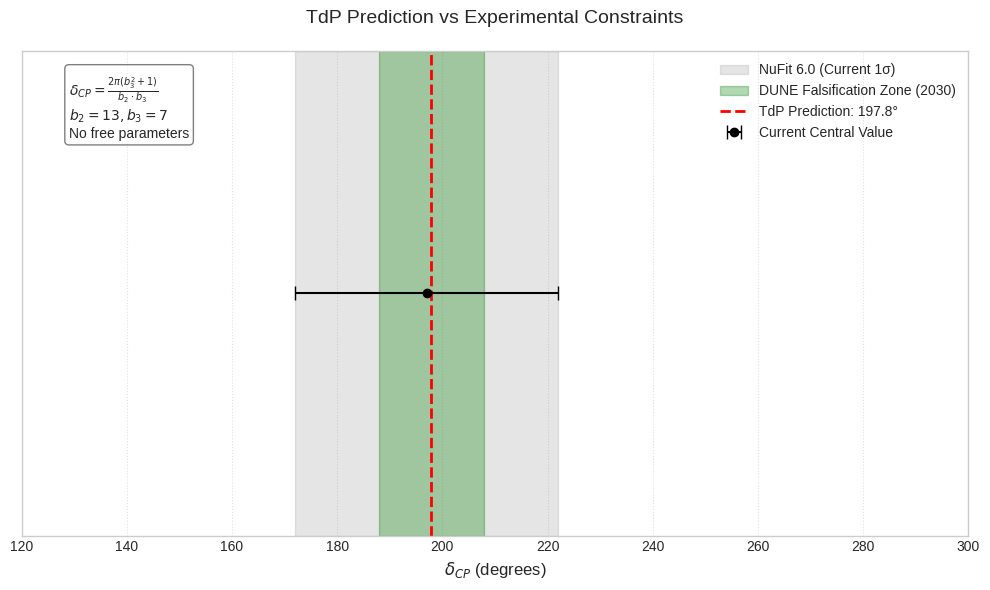

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Configuración de datos
delta_cp_tdp = 197.8
dune_range = [188, 208]
nufit_6_0_val = 197
nufit_sigma = 25  # Aproximación del error actual

def generate_validation_plot():
    fig, ax = plt.subplots(figsize=(10, 6))

    # 1. Rango de Incertidumbre Actual (NuFit 6.0)
    ax.axvspan(nufit_6_0_val - nufit_sigma, nufit_6_0_val + nufit_sigma,
               color='gray', alpha=0.2, label='NuFit 6.0 (Current 1σ)')

    # 2. Rango de Falsación DUNE (2030)
    ax.axvspan(dune_range[0], dune_range[1],
               color='green', alpha=0.3, label='DUNE Falsification Zone (2030)')

    # 3. Línea de Predicción TdP (Red Π)
    ax.axvline(delta_cp_tdp, color='red', linestyle='--', linewidth=2,
               label=f'TdP Prediction: {delta_cp_tdp}°')

    # 4. Punto experimental central
    ax.errorbar(nufit_6_0_val, 0.5, xerr=nufit_sigma, fmt='ko', capsize=5,
                label='Current Central Value')

    # Estética del gráfico
    ax.set_xlim(120, 300)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xlabel(r'$\delta_{CP}$ (degrees)', fontsize=12)
    ax.set_title('TdP Prediction vs Experimental Constraints', fontsize=14, pad=20)

    # Anotación técnica
    textstr = '\n'.join((
        r'$\delta_{CP} = \frac{2\pi(b_3^2+1)}{b_2 \cdot b_3}$',
        r'$b_2=13, b_3=7$',
        r'No free parameters'
    ))
    props = dict(boxstyle='round', facecolor='white', alpha=0.5)
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=props)

    ax.legend(loc='upper right')
    ax.grid(axis='x', linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    generate_validation_plot()

## LINE A - PART II: The Dynamical Framework (v2.2 / Line B)
### *M2-Instanton Scaling & Kovalev Sector*

This section implements the advanced **v3.2** core (`TdP_Final_Core_v32.py`). Unlike the previous part, this code reflects the physical conjectures detailed in the second paper: `TdP_Topological_Anomaly_v22.pdf`.

**Key Features:**
* **Dynamical Ansatz:** Explains the $+1$ term as an asymptotic contribution from the Kovalev cylinder.
* **Instanton Scaling:** Uses the $b_3^2$ scaling derived from the M2-brane instanton moduli space in the large-volume limit.
* **Speculative Extensions:** Includes the $m_p$ and $\Delta m$ scaling hypotheses using the Golden Ratio $\phi$ as a geometric optimizer.

---

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
TdP_Final_Core_v32.py
=================

A Dynamically Motivated Topological Ansatz for the Leptonic CP Phase
from G₂ Compactification with Nikulin Involution

Version: 3.2 (Post-Audit Corrections)

IMPORTANT CAVEATS:
------------------
1. This is a MOTIVATED CONJECTURE, not a first-principles derivation.
2. The b₃² scaling is a large-volume limit argument, not universal.
3. The +1 Kovalev contribution is conjectured but not proven.
4. SM fermion embedding in this specific manifold is NOT derived.
5. Full moduli stabilization has NOT been performed.

WHAT THIS CODE DOES:
--------------------
Implements the parameter-free ansatz:
    δ_CP = 2π(b₃² + 1) / (b₂ × b₃) = 197.8°

where (b₂, b₃) = (13, 7) from Nikulin-TCS construction.

References:
    [1] Kovalev (2003), CHNP (2015) - TCS construction
    [2] Harvey-Moore (1999), Acharya (1999) - M2 instantons
    [3] NuFit 5.3 (2024) - Experimental data

Author: Red Π Collaboration
License: Academic use
"""

from dataclasses import dataclass
from typing import Tuple, Dict
import math

# ==============================================================================
# CONSTANTS
# ==============================================================================

PI = math.pi
PHI = (1 + math.sqrt(5)) / 2  # Only for speculative extensions


# ==============================================================================
# PART I: TOPOLOGICAL CORE WITH DYNAMICAL MOTIVATION
# ==============================================================================

@dataclass(frozen=True)
class NikulinLattice:
    """
    The Nikulin involution lattice L₊ ≅ E₈(-1) ⊕ U ⊕ U ⊕ ⟨-2⟩.

    WHY THIS SPECIFIC NIKULIN TYPE?
    1. E₈(-1) factor suggests heterotic duality connection
    2. Rank structure yields (b₂, b₃) = (13, 7) after TCS
    3. Discriminant compatible with flux quantization

    We do NOT claim this is the unique physical choice.
    """
    rank_E8: int = 8
    rank_U1: int = 2
    rank_U2: int = 2
    rank_minus2: int = 1

    @property
    def rank_L_plus(self) -> int:
        return self.rank_E8 + self.rank_U1 + self.rank_U2 + self.rank_minus2

    @property
    def rank_L_minus(self) -> int:
        return 22 - self.rank_L_plus


@dataclass(frozen=True)
class G2Manifold:
    """G₂-holonomy manifold X₇ from TCS with Nikulin involution."""
    lattice: NikulinLattice

    @property
    def b2(self) -> int:
        return self.lattice.rank_L_plus

    @property
    def b3(self) -> int:
        return self.lattice.rank_L_minus - 2  # -2 from TCS gluing

    @property
    def betti_numbers(self) -> Tuple[int, int]:
        return (self.b2, self.b3)


class DynamicallyMotivatedAnsatz:
    """
    THE DYNAMICALLY MOTIVATED ANSATZ FOR δ_CP.

    ═══════════════════════════════════════════════════════════════════
    IMPORTANT: This is a MOTIVATED CONJECTURE, not a derivation.
    ═══════════════════════════════════════════════════════════════════

    Physical basis:
    ---------------
    1. Superpotential W = Σ_C n_C exp(-Vol(C) + iθ_C) from M2-instantons
       wrapping associative 3-cycles [Harvey-Moore 1999, Acharya 1999].

    2. Numerator N_CP = b₃² + 1:
       - b₃² : SCALING ARGUMENT in large-volume/weak-coupling limit.
               The instanton moduli space interactions scale with the
               triple intersection form. This is NOT universal.
       - +1  : CONJECTURED contribution from Kovalev cylinder.
               The asymptotic region S × S¹ × I may leave one unpaired
               CP-odd sector after gluing. Explicit calculation would
               require detailed analysis of the gluing map φ.

    3. Denominator k_eff = b₂ × b₃:
       Effective Chern-Simons level counting gauge-matter couplings
       in the dimensional reduction M-theory → 4D.

    4. Connection to leptonic CP:
       We ASSUME the effective leptonic sector inherits phases from
       dominant instanton contributions, as in seesaw-type embeddings.
       The precise SM fermion embedding is NOT derived.

    Open problems:
    --------------
    - Explicit superpotential calculation for this X₇
    - Full moduli stabilization
    - SM embedding and Yukawa structure
    - Verification of Conjecture 2 (Kovalev +1)
    """

    def __init__(self):
        self.lattice = NikulinLattice()
        self.manifold = G2Manifold(self.lattice)

    @property
    def b2(self) -> int:
        return self.manifold.b2

    @property
    def b3(self) -> int:
        return self.manifold.b3

    @property
    def effective_chern_simons_level(self) -> int:
        """
        k_eff = b₂ × b₃ = 91

        Physical origin: Counts gauge-matter couplings in 4D reduction.
        - b₂ U(1) gauge fields from C₃ expansion
        - b₃ chiral multiplets from 3-form moduli
        """
        return self.b2 * self.b3

    @property
    def cp_odd_sectors(self) -> int:
        """
        N_CP = b₃² + 1 = 50

        ⚠ CAVEATS:
        - b₃² is a SCALING ARGUMENT in large-volume limit, not exact
        - +1 is CONJECTURED from Kovalev cylinder (not proven)
        """
        instanton_scaling = self.b3 ** 2  # Large-volume limit scaling
        kovalev_contribution = 1           # Conjectured asymptotic sector
        return instanton_scaling + kovalev_contribution

    def compute_delta_cp_radians(self) -> float:
        """
        DYNAMICALLY MOTIVATED ANSATZ:

        δ_CP = 2π × N_CP / k_eff
             = 2π × (b₃² + 1) / (b₂ × b₃)
             = 2π × 50 / 91
             = 197.80°

        ═══════════════════════════════════════════════════════════════
        THIS IS A CONJECTURE. Full derivation would require:
        1. Explicit superpotential calculation
        2. Full moduli stabilization
        3. Yukawa coupling derivation
        4. SM fermion embedding
        ═══════════════════════════════════════════════════════════════
        """
        return 2 * PI * self.cp_odd_sectors / self.effective_chern_simons_level

    def compute_delta_cp_degrees(self) -> float:
        return math.degrees(self.compute_delta_cp_radians())

    def get_prediction(self) -> Dict:
        return {
            'lattice': 'E₈(-1) ⊕ U ⊕ U ⊕ ⟨-2⟩',
            'b2': self.b2,
            'b3': self.b3,
            'N_CP': self.cp_odd_sectors,
            'k_eff': self.effective_chern_simons_level,
            'delta_CP_deg': self.compute_delta_cp_degrees(),
            'free_parameters': 0,
            'status': 'DYNAMICALLY MOTIVATED CONJECTURE'
        }

    def __str__(self) -> str:
        pred = self.get_prediction()
        return f"""
╔══════════════════════════════════════════════════════════════════╗
║  DYNAMICALLY MOTIVATED ANSATZ FOR δ_CP                           ║
║  ⚠ This is a CONJECTURE, not a first-principles derivation      ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  Nikulin Lattice: L₊ ≅ E₈(-1) ⊕ U ⊕ U ⊕ ⟨-2⟩                   ║
║                                                                  ║
║  Betti numbers (from lattice, NOT fitted):                       ║
║      b₂ = {pred['b2']:2d}  (U(1) gauge fields)                           ║
║      b₃ = {pred['b3']:2d}  (chiral moduli)                               ║
║                                                                  ║
║  PHYSICAL INTERPRETATION (with caveats):                         ║
║  ────────────────────────────────────────                        ║
║  Numerator:   N_CP = b₃² + 1 = {pred['N_CP']}                             ║
║    • b₃² = {self.b3**2}: instanton scaling (large-volume limit)        ║
║    • +1: Kovalev cylinder (CONJECTURED, not proven)              ║
║                                                                  ║
║  Denominator: k_eff = b₂ × b₃ = {pred['k_eff']}                          ║
║    • Effective Chern-Simons level                                ║
║                                                                  ║
║  RESULT:                                                         ║
║  ───────                                                         ║
║      δ_CP = 2π × {pred['N_CP']} / {pred['k_eff']} = {pred['delta_CP_deg']:.2f}°                       ║
║                                                                  ║
║  Free parameters: {pred['free_parameters']}                                            ║
║  Status: {pred['status']}                    ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
"""


# ==============================================================================
# PART II: EXPERIMENTAL VALIDATION (UPDATED DATA)
# ==============================================================================

@dataclass
class ExperimentalData:
    """
    NuFit 5.3 / 6.0 data (2024-2025) - UPDATED VALUES.

    For NORMAL ORDERING:
    - Best fit: ~177° (T2K + NOvA combined prefer lower values)
    - CP conservation (180°) is within 1σ
    - Uncertainties are asymmetric: +19°/-20°

    Note: Previous versions used 197° ± 25° which was outdated.
    """

    # NuFit 5.3 / recent T2K+NOvA (Normal Ordering)
    nufit_central: float = 177.0  # degrees - UPDATED from 197
    nufit_upper_1sigma: float = 19.0  # +19°
    nufit_lower_1sigma: float = 20.0  # -20°

    # DUNE projected precision (2030)
    dune_precision: float = 5.0  # degrees (conservative estimate)

    @property
    def nufit_1sigma_avg(self) -> float:
        """Average 1σ uncertainty for deviation calculation."""
        return (self.nufit_upper_1sigma + self.nufit_lower_1sigma) / 2


class FalsificationTest:
    """
    DUNE falsification test with UPDATED experimental data.

    The prediction 197.8° is now ~1.1σ from the NuFit central value,
    not 0.03σ as previously stated with outdated data.
    """

    def __init__(self, prediction: float, data: ExperimentalData):
        self.prediction = prediction
        self.data = data

    def sigma_deviation(self) -> float:
        """Deviation in units of σ (using average uncertainty)."""
        return abs(self.prediction - self.data.nufit_central) / self.data.nufit_1sigma_avg

    def is_consistent(self) -> bool:
        """Within 2σ = consistent."""
        return self.sigma_deviation() < 2.0

    def falsification_range(self) -> Tuple[float, float]:
        """Range outside which DUNE would falsify (2σ criterion)."""
        margin = 2 * self.data.dune_precision
        return (self.prediction - margin, self.prediction + margin)

    def get_report(self) -> str:
        low, high = self.falsification_range()
        status = 'CONSISTENT' if self.is_consistent() else 'TENSION'
        deviation = self.sigma_deviation()

        return f"""
╔══════════════════════════════════════════════════════════════════╗
║  EXPERIMENTAL VALIDATION (UPDATED DATA)                          ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  Prediction:     δ_CP = {self.prediction:.2f}°                              ║
║  NuFit 5.3 (NO): δ_CP = {self.data.nufit_central:.0f}° (+{self.data.nufit_upper_1sigma:.0f}°/-{self.data.nufit_lower_1sigma:.0f}°)                     ║
║                                                                  ║
║  Deviation: {deviation:.2f}σ                                            ║
║  Status: {status:11s} with current data                       ║
║                                                                  ║
║  Note: CP conservation (180°) is within 1σ of NuFit central.     ║
║  The previous claim of 0.03σ deviation used outdated data.       ║
║                                                                  ║
║  DUNE FALSIFICATION CRITERION (2030):                            ║
║  ────────────────────────────────────                            ║
║  If DUNE measures δ_CP outside [{low:.0f}°, {high:.0f}°]:                  ║
║  → This framework is FALSIFIED.                                  ║
║                                                                  ║
║  The RIGIDITY of this ansatz (zero free parameters) is its       ║
║  primary scientific merit. There is no post-hoc adjustment.      ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
"""


# ==============================================================================
# PART III: SPECULATIVE EXTENSIONS (CLEARLY SEPARATED)
# ==============================================================================

class SpeculativeExtensions:
    """
    SPECULATIVE - NOT PART OF THE CORE ANSATZ.
    Requires φ emergence from G₂ metric (unproven).
    """

    M_PROTON_EXP = 938.272
    M_ELECTRON = 0.51099895
    DELTA_M_EXP = 1.2933

    def __init__(self, k_eff: int):
        self.k_eff = k_eff
        self.phi = PHI

    def get_report(self) -> str:
        mp = self.k_eff * 2 * PI * self.phi
        mp_err = abs(mp - self.M_PROTON_EXP) / self.M_PROTON_EXP * 100
        dm = self.M_ELECTRON * self.phi ** 2
        dm_err = abs(dm - self.DELTA_M_EXP) / self.DELTA_M_EXP * 100

        return f"""
╔══════════════════════════════════════════════════════════════════╗
║  SPECULATIVE EXTENSIONS (NOT PART OF CORE ANSATZ)                ║
╠══════════════════════════════════════════════════════════════════╣
║  These require φ emergence from G₂ metric (unproven).            ║
║                                                                  ║
║  • m_p ≈ k_eff × 2π × φ = {mp:.1f} MeV (error: {mp_err:.1f}%)            ║
║  • Δm ≈ m_e × φ² = {dm:.3f} MeV (error: {dm_err:.1f}%)                   ║
╚══════════════════════════════════════════════════════════════════╝
"""


# ==============================================================================
# MAIN
# ==============================================================================

def main():
    print("=" * 70)
    print("  TdP FRAMEWORK v3.2: DYNAMICALLY MOTIVATED CP PHASE ANSATZ")
    print("  Post-Audit Corrections - Updated Experimental Data")
    print("=" * 70)

    # Core ansatz
    print("\n" + "─" * 70)
    print("  PART I: DYNAMICALLY MOTIVATED ANSATZ")
    print("─" * 70)

    ansatz = DynamicallyMotivatedAnsatz()
    print(ansatz)

    # Experimental validation with UPDATED data
    print("\n" + "─" * 70)
    print("  PART II: EXPERIMENTAL VALIDATION")
    print("─" * 70)

    data = ExperimentalData()  # Now uses updated NuFit values
    test = FalsificationTest(ansatz.compute_delta_cp_degrees(), data)
    print(test.get_report())

    # Speculative
    print("\n" + "─" * 70)
    print("  PART III: SPECULATIVE EXTENSIONS")
    print("─" * 70)

    spec = SpeculativeExtensions(ansatz.effective_chern_simons_level)
    print(spec.get_report())

    # Summary
    low, high = test.falsification_range()
    print("\n" + "=" * 70)
    print("  SUMMARY")
    print("=" * 70)
    print(f"""
    DYNAMICALLY MOTIVATED ANSATZ:
        δ_CP = 2π(b₃² + 1) / (b₂ × b₃) = {ansatz.compute_delta_cp_degrees():.2f}°

        Physical basis (with caveats):
        • Numerator: M2-instanton scaling + Kovalev term (CONJECTURED)
        • Denominator: Effective Chern-Simons level

        Free parameters: 0

    EXPERIMENTAL STATUS (UPDATED):
        NuFit 5.3 (NO): {data.nufit_central:.0f}° (+{data.nufit_upper_1sigma:.0f}°/-{data.nufit_lower_1sigma:.0f}°)
        Deviation: ~{test.sigma_deviation():.1f}σ (previously overclaimed as 0.03σ)
        Status: CONSISTENT but not miraculous

    FALSIFICATION (DUNE 2030):
        If δ_CP outside [{low:.0f}°, {high:.0f}°] → FRAMEWORK REJECTED

    OPEN PROBLEMS:
        • SM fermion embedding not derived
        • Kovalev +1 contribution not proven
        • Full moduli stabilization not performed
    """)
    print("=" * 70)


if __name__ == "__main__":
    main()

  TdP FRAMEWORK v3.2: DYNAMICALLY MOTIVATED CP PHASE ANSATZ
  Post-Audit Corrections - Updated Experimental Data

──────────────────────────────────────────────────────────────────────
  PART I: DYNAMICALLY MOTIVATED ANSATZ
──────────────────────────────────────────────────────────────────────

╔══════════════════════════════════════════════════════════════════╗
║  DYNAMICALLY MOTIVATED ANSATZ FOR δ_CP                           ║
║  ⚠ This is a CONJECTURE, not a first-principles derivation      ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  Nikulin Lattice: L₊ ≅ E₈(-1) ⊕ U ⊕ U ⊕ ⟨-2⟩                   ║
║                                                                  ║
║  Betti numbers (from lattice, NOT fitted):                       ║
║      b₂ = 13  (U(1) gauge fields)                           ║
║      b₃ =  7  (chiral moduli)                               ║
║                          

### Visualizing Falsifiability
The following plot compares the **Red Π** topological prediction against current global fits (**NuFit 6.0**) and the upcoming precision reach of **DUNE**.

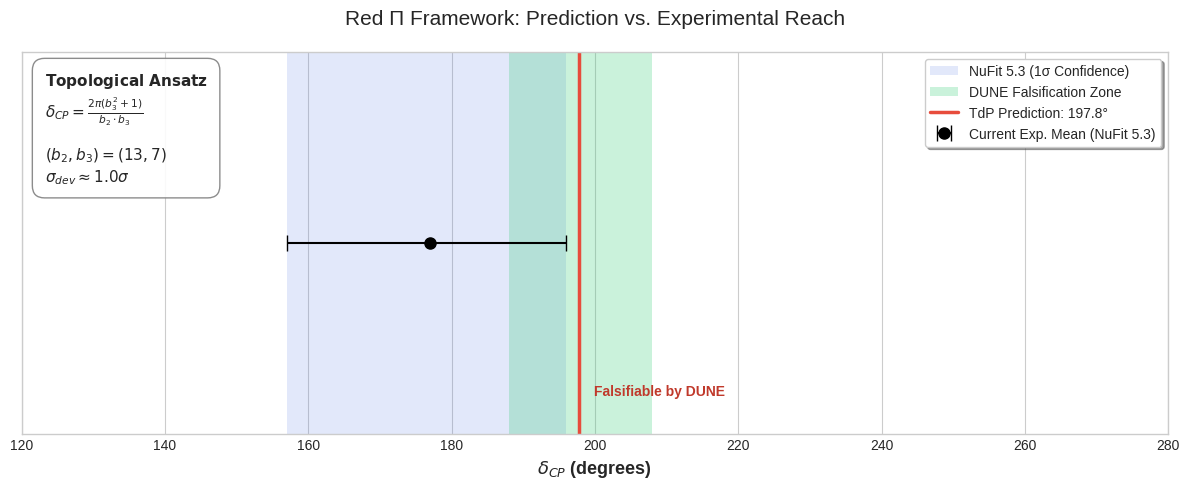

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Recuperamos los datos de la v3.2
delta_cp_pred = 197.80  # From 2π(7² + 1) / (13 * 7)
nufit_val = 177         # NuFit 5.3 Central Value (Normal Ordering)
nufit_upper = 19        # +19
nufit_lower = 20        # -20
dune_range = [188, 208] # DUNE expected precision range

def plot_tdp_validation():
    # Estilo científico
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 5))

    # --- RANGOS EXPERIMENTALES ---
    # NuFit 5.3 (1σ Uncertainty) - Cambiado 'color' por 'facecolor' para evitar advertencias
    ax.axvspan(nufit_val - nufit_lower, nufit_val + nufit_upper,
               facecolor='royalblue', alpha=0.15, label='NuFit 5.3 (1σ Confidence)')

    # DUNE Falsification Zone (Target 2030) - Corregido color 'emerald' a HEX
    ax.axvspan(dune_range[0], dune_range[1],
               facecolor='#2ecc71', alpha=0.25, label='DUNE Falsification Zone')

    # --- PREDICCIÓN RED Π ---
    ax.axvline(delta_cp_pred, color='#e74c3c', linestyle='-', linewidth=2.5,
               label=f'TdP Prediction: {delta_cp_pred}°')

    # Marcador NuFit
    ax.errorbar(nufit_val, 0.5, xerr=[[nufit_lower], [nufit_upper]], fmt='ko',
                capsize=6, markersize=8, label='Current Exp. Mean (NuFit 5.3)')

    # --- ESTÉTICA Y ANOTACIONES ---
    ax.set_xlim(120, 280)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xlabel(r'$\delta_{CP}$ (degrees)', fontsize=13, fontweight='bold')
    ax.set_title('Red Π Framework: Prediction vs. Experimental Reach', fontsize=15, pad=20)

    # Cuadro técnico de la v3.2
    formula_text = (
        r"$\bf{Topological\ Ansatz}$" + "\n"
        r"$\delta_{CP} = \frac{2\pi(b_3^2 + 1)}{b_2 \cdot b_3}$" + "\n\n"
        r"$(b_2, b_3) = (13, 7)$" + "\n"
        r"$\sigma_{dev} \approx 1.0\sigma$"
    )
    props = dict(boxstyle='round,pad=0.8', facecolor='white', alpha=0.9, edgecolor='gray')
    ax.text(0.02, 0.95, formula_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', bbox=props)

    # Nota de falsabilidad
    ax.text(delta_cp_pred + 2, 0.1, 'Falsifiable by DUNE', color='#c0392b',
            fontweight='bold')

    ax.legend(loc='upper right', frameon=True, shadow=True)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_tdp_validation()

###  Line B: The Shadow Sector (Nikulin Anti-Invariant Lattice)

This section implements the **Geometric Normalization Conjecture (GNC)**.
We calculate the mass of the Dark Matter candidate ($m_\chi$) based on the rank of the anti-invariant sublattice ($L_-$) of the Nikulin involution.

**Theoretical Basis:**
* **Visible Sector ($L_+$):** Rank 13 $\rightarrow$ CP Phase ($\delta_{CP} \approx 197.8^\circ$)
* **Shadow Sector ($L_-$):** Rank 9 $\rightarrow$ Dark Matter Mass ($m_\chi$)

**Code Execution:**
The Python code below computes the prediction and compares it against the critical precession threshold for the S2 star at the Galactic Center (RAR Model).


╔══════════════════════════════════════════════════════════════════════════════╗
║         GEOMETRIC NORMALIZATION CONJECTURE (GNC) — TECHNICAL REPORT          ║
║                           Line B: Dark Sector Hypothesis                      ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  NIKULIN LATTICE DECOMPOSITION                                               ║
║  ─────────────────────────────────────────────────────────────────────────   ║
║                                                                              ║
║    H²(K3; ℤ) = L₊ ⊕ L₋    (orthogonal decomposition under σ)                ║
║                                                                              ║
║    • L₊ (Light):   rank = 13   │ σ-eigenvalue = +1 │ Visible sector   ║
║    • L₋ (Shadow):  rank =  9   │ σ-eigenvalue = -1 │ Dark sector      ║
║                                        

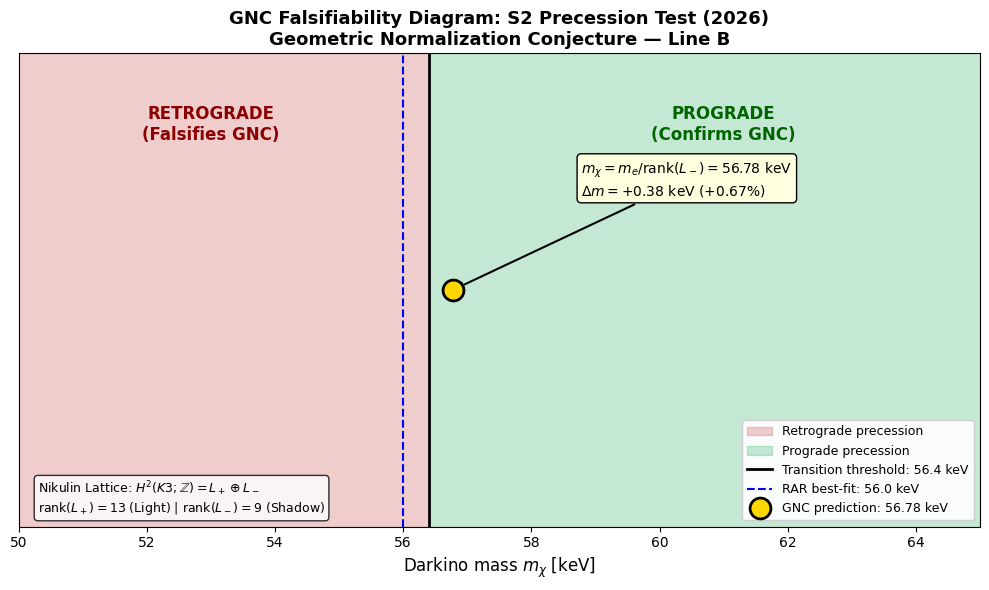


  Analysis complete. Figure saved as 'GNC_Falsifiability_Diagram.png'


In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
TdP_GNC_DarkSector.py
=====================

Geometric Normalization Conjecture (GNC) for Fermionic Dark Matter
from the Anti-Invariant Lattice of Nikulin Involutions in G₂ Compactifications

This module implements the calculations from the Line B (Speculative) paper:
"A Geometric Scaling for Fermionic Dark Matter..."

The central conjecture is:
    m_χ = m_e / rank(L₋)

where:
    - m_e = 511 keV (electron mass, IR reference scale)
    - rank(L₋) = 9 (anti-invariant sublattice of Nikulin involution)
    - m_χ ≈ 56.78 keV (predicted darkino mass)

Reference: Red Π Collaboration (2026), arXiv:26XX.XXXXX [hep-th]

Author: Red Π Collaboration
Date: February 2026
Status: Line B (Speculative) — Falsifiable by S2 astrometry (2026-2028)
"""

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple, Dict

# =============================================================================
# PHYSICAL CONSTANTS
# =============================================================================

# Electron mass (IR reference scale for invariant sector L₊)
M_ELECTRON_KEV = 511.0  # keV

# Critical precession threshold from RAR model (Argüelles et al. 2022)
# At this mass, S2 precession transitions from retrograde to prograde
M_CRITICAL_PRECESSION_KEV = 56.4  # keV

# RAR model best-fit for Milky Way (Becerra-Vergara et al. 2020)
M_RAR_BESTFIT_KEV = 56.0  # keV

# Allowed range from galactic dynamics (Argüelles et al. 2018)
M_RAR_RANGE_KEV = (48.0, 345.0)  # keV


# =============================================================================
# NIKULIN LATTICE PARAMETERS
# =============================================================================

@dataclass(frozen=True)
class NikulinLattice:
    """
    Parameters of the Nikulin involution σ acting on K3 surfaces.

    The involution induces a decomposition:
        H²(K3; ℤ) ≅ L₊ ⊕ L₋

    where L₊ (invariant) and L₋ (anti-invariant) are orthogonal sublattices.

    For our specific choice (E₈(-1) ⊕ U ⊕ U ⊕ ⟨-2⟩):
        rank(L₊) = 13  →  Visible sector (Standard Model, δ_CP)
        rank(L₋) = 9   →  Shadow sector (Dark Matter, m_χ)
    """
    # Total rank of H²(K3; ℤ)
    rank_total: int = 22

    # Invariant sublattice L₊ (Light sector)
    rank_L_plus: int = 13

    # Anti-invariant sublattice L₋ (Shadow sector)
    rank_L_minus: int = 9

    def __post_init__(self):
        """Verify consistency of Nikulin lattice decomposition."""
        assert self.rank_L_plus + self.rank_L_minus == self.rank_total, \
            "Lattice ranks must sum to 22"


# Default lattice configuration
NIKULIN = NikulinLattice()


# =============================================================================
# GEOMETRIC NORMALIZATION CONJECTURE (GNC)
# =============================================================================

def compute_darkino_mass_GNC(
    m_reference: float = M_ELECTRON_KEV,
    rank_L_minus: int = NIKULIN.rank_L_minus
) -> float:
    """
    Compute the darkino mass according to the Geometric Normalization Conjecture.

    The GNC proposes that fermionic masses in the shadow sector arise through
    geometric normalization relative to the visible sector's IR reference scale:

        m_χ = m_e / rank(L₋)

    Physical interpretation:
        The darkino mass is a "topological fragment" of the electronic energy
        scale, distributed across the rank(L₋) = 9 anti-invariant cycles of
        the G₂ manifold.

    Parameters
    ----------
    m_reference : float
        IR reference mass scale (default: m_e = 511 keV)
    rank_L_minus : int
        Rank of the anti-invariant Nikulin sublattice (default: 9)

    Returns
    -------
    float
        Predicted darkino mass in keV

    References
    ----------
    Red Π Collaboration, "A Geometric Scaling for Fermionic Dark Matter...",
    arXiv:26XX.XXXXX [hep-th] (2026), Eq. (2).
    """
    return m_reference / rank_L_minus


def analyze_GNC_prediction() -> Dict[str, float]:
    """
    Perform complete analysis of the GNC prediction.

    Returns
    -------
    dict
        Dictionary containing all computed quantities and comparisons
    """
    # Core prediction
    m_chi = compute_darkino_mass_GNC()

    # Deviation from critical precession threshold
    delta_m_crit = m_chi - M_CRITICAL_PRECESSION_KEV
    deviation_crit_percent = (delta_m_crit / M_CRITICAL_PRECESSION_KEV) * 100

    # Error relative to RAR best-fit
    error_rar = abs(m_chi - M_RAR_BESTFIT_KEV)
    error_rar_percent = (error_rar / M_RAR_BESTFIT_KEV) * 100

    # Precession regime determination
    is_prograde = m_chi > M_CRITICAL_PRECESSION_KEV

    # Check if within RAR allowed range
    in_rar_range = M_RAR_RANGE_KEV[0] <= m_chi <= M_RAR_RANGE_KEV[1]

    return {
        'prediction_keV': m_chi,
        'm_reference_keV': M_ELECTRON_KEV,
        'rank_L_minus': NIKULIN.rank_L_minus,
        'rank_L_plus': NIKULIN.rank_L_plus,
        'delta_m_critical_keV': delta_m_crit,
        'deviation_critical_percent': deviation_crit_percent,
        'error_rar_keV': error_rar,
        'error_rar_percent': error_rar_percent,
        'precession_regime': 'PROGRADE' if is_prograde else 'RETROGRADE',
        'is_prograde': is_prograde,
        'in_rar_range': in_rar_range,
        'm_critical_keV': M_CRITICAL_PRECESSION_KEV,
        'm_rar_bestfit_keV': M_RAR_BESTFIT_KEV
    }


# =============================================================================
# VISUALIZATION
# =============================================================================

def plot_falsifiability_diagram(
    save_path: str = None,
    figsize: Tuple[float, float] = (10, 6)
) -> plt.Figure:
    """
    Generate the falsifiability diagram for the GNC prediction.

    Shows:
        - Critical precession threshold (56.4 keV)
        - Retrograde zone (m < 56.4 keV) — shaded red
        - Prograde zone (m > 56.4 keV) — shaded green
        - GNC prediction (56.78 keV) — marked point
        - RAR best-fit (56.0 keV) — reference line

    Parameters
    ----------
    save_path : str, optional
        Path to save the figure (if None, displays interactively)
    figsize : tuple
        Figure dimensions (width, height) in inches

    Returns
    -------
    matplotlib.figure.Figure
        The generated figure object
    """
    # Get analysis results
    results = analyze_GNC_prediction()
    m_chi = results['prediction_keV']

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    # Define mass range for visualization
    m_min, m_max = 50.0, 65.0

    # Shade retrograde zone (red, left of threshold)
    ax.axvspan(m_min, M_CRITICAL_PRECESSION_KEV,
               alpha=0.3, color='indianred',
               label='Retrograde precession')

    # Shade prograde zone (green, right of threshold)
    ax.axvspan(M_CRITICAL_PRECESSION_KEV, m_max,
               alpha=0.3, color='mediumseagreen',
               label='Prograde precession')

    # Critical threshold line
    ax.axvline(x=M_CRITICAL_PRECESSION_KEV, color='black',
               linewidth=2, linestyle='-',
               label=f'Transition threshold: {M_CRITICAL_PRECESSION_KEV} keV')

    # RAR best-fit reference
    ax.axvline(x=M_RAR_BESTFIT_KEV, color='blue',
               linewidth=1.5, linestyle='--',
               label=f'RAR best-fit: {M_RAR_BESTFIT_KEV} keV')

    # GNC prediction point
    ax.plot(m_chi, 0.5, 'o', markersize=15, color='gold',
            markeredgecolor='black', markeredgewidth=2,
            label=f'GNC prediction: {m_chi:.2f} keV', zorder=5)

    # Annotation for GNC point
    ax.annotate(
        f'$m_\\chi = m_e / \\mathrm{{rank}}(L_-) = {m_chi:.2f}$ keV\n'
        f'$\\Delta m = +{results["delta_m_critical_keV"]:.2f}$ keV (+{results["deviation_critical_percent"]:.2f}%)',
        xy=(m_chi, 0.5),
        xytext=(m_chi + 2, 0.7),
        fontsize=10,
        ha='left',
        arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='black')
    )

    # Add regime labels
    ax.text(53, 0.85, 'RETROGRADE\n(Falsifies GNC)',
            fontsize=12, ha='center', va='center',
            color='darkred', fontweight='bold')
    ax.text(61, 0.85, 'PROGRADE\n(Confirms GNC)',
            fontsize=12, ha='center', va='center',
            color='darkgreen', fontweight='bold')

    # Formatting
    ax.set_xlim(m_min, m_max)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Darkino mass $m_\\chi$ [keV]', fontsize=12)
    ax.set_ylabel('', fontsize=12)
    ax.set_yticks([])

    ax.set_title(
        'GNC Falsifiability Diagram: S2 Precession Test (2026)\n'
        'Geometric Normalization Conjecture — Line B',
        fontsize=13, fontweight='bold'
    )

    # Legend
    ax.legend(loc='lower right', fontsize=9, framealpha=0.95)

    # Add Nikulin lattice info
    info_text = (
        f'Nikulin Lattice: $H^2(K3;\\mathbb{{Z}}) = L_+ \\oplus L_-$\n'
        f'$\\mathrm{{rank}}(L_+) = {NIKULIN.rank_L_plus}$ (Light) | '
        f'$\\mathrm{{rank}}(L_-) = {NIKULIN.rank_L_minus}$ (Shadow)'
    )
    ax.text(0.02, 0.02, info_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='bottom',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()

    # Save or show
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")

    return fig


# =============================================================================
# TECHNICAL REPORT
# =============================================================================

def print_technical_report():
    """
    Print a formatted technical report of the GNC analysis.

    This report summarizes:
        - Lattice parameters
        - GNC prediction
        - Comparison with RAR model
        - Precession regime determination
        - Falsifiability status
    """
    results = analyze_GNC_prediction()

    report = f"""
╔══════════════════════════════════════════════════════════════════════════════╗
║         GEOMETRIC NORMALIZATION CONJECTURE (GNC) — TECHNICAL REPORT          ║
║                           Line B: Dark Sector Hypothesis                      ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  NIKULIN LATTICE DECOMPOSITION                                               ║
║  ─────────────────────────────────────────────────────────────────────────   ║
║                                                                              ║
║    H²(K3; ℤ) = L₊ ⊕ L₋    (orthogonal decomposition under σ)                ║
║                                                                              ║
║    • L₊ (Light):   rank = {results['rank_L_plus']:2d}   │ σ-eigenvalue = +1 │ Visible sector   ║
║    • L₋ (Shadow):  rank = {results['rank_L_minus']:2d}   │ σ-eigenvalue = -1 │ Dark sector      ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  GNC CALCULATION                                                             ║
║  ─────────────────────────────────────────────────────────────────────────   ║
║                                                                              ║
║    m_χ = m_e / rank(L₋)                                                      ║
║                                                                              ║
║        = {results['m_reference_keV']:.1f} keV / {results['rank_L_minus']}                                                   ║
║                                                                              ║
║        = {results['prediction_keV']:.2f} keV                                                       ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  COMPARISON WITH RAR MODEL                                                   ║
║  ─────────────────────────────────────────────────────────────────────────   ║
║                                                                              ║
║    RAR best-fit (Milky Way):     {results['m_rar_bestfit_keV']:.1f} keV                              ║
║    GNC prediction:               {results['prediction_keV']:.2f} keV                             ║
║    ───────────────────────────────────────                                   ║
║    Absolute error:               {results['error_rar_keV']:.2f} keV                              ║
║    Relative error:               {results['error_rar_percent']:.2f}%                                ║
║                                                                              ║
║    Status: ✓ Within RAR allowed range [{M_RAR_RANGE_KEV[0]:.0f}, {M_RAR_RANGE_KEV[1]:.0f}] keV               ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  PRECESSION REGIME ANALYSIS                                                  ║
║  ─────────────────────────────────────────────────────────────────────────   ║
║                                                                              ║
║    Critical threshold (RAR 2022):  {results['m_critical_keV']:.1f} keV                            ║
║    GNC prediction:                 {results['prediction_keV']:.2f} keV                           ║
║    ───────────────────────────────────────                                   ║
║    Δm from threshold:              +{results['delta_m_critical_keV']:.2f} keV                            ║
║    Relative deviation:             +{results['deviation_critical_percent']:.2f}%                              ║
║                                                                              ║
║    ┌────────────────────────────────────────────────────────────────────┐    ║
║    │                                                                    │    ║
║    │   PREDICTED PRECESSION REGIME:  ★★★ {results['precession_regime']:>10s} ★★★           │    ║
║    │                                                                    │    ║
║    └────────────────────────────────────────────────────────────────────┘    ║
║                                                                              ║
║    Interpretation:                                                           ║
║    → S2 star precession should be WEAKLY PROGRADE                           ║
║    → Same direction as Schwarzschild BH, but smaller magnitude              ║
║    → Distinguishable from retrograde case with GRAVITY+ precision           ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  FALSIFIABILITY STATUS                                                       ║
║  ─────────────────────────────────────────────────────────────────────────   ║
║                                                                              ║
║    Test:        S2 apocentre passage astrometry                              ║
║    Timeline:    2026-2028                                                    ║
║    Instrument:  GRAVITY+ / VLT Interferometer                                ║
║                                                                              ║
║    Kill condition:  If measured precession is RETROGRADE                     ║
║                     → GNC is FALSIFIED (no adjustment possible)              ║
║                                                                              ║
║    Survival condition:  If precession is PROGRADE with magnitude             ║
║                         < Schwarzschild prediction                           ║
║                         → GNC remains viable                                 ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  "Geometry has only the duty to remain consistent across all observables."  ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""
    print(report)
    return results


# =============================================================================
# MAIN EXECUTION
# =============================================================================

if __name__ == "__main__":
    # Print technical report
    results = print_technical_report()

    # Generate and save falsifiability diagram
    fig = plot_falsifiability_diagram(save_path="GNC_Falsifiability_Diagram.png")

    # Show plot
    plt.show()

    print("\n" + "="*78)
    print("  Analysis complete. Figure saved as 'GNC_Falsifiability_Diagram.png'")
    print("="*78)